---
title: "Dichotomous Item Response Theory Models with NumPyro"
date: 2025-03-10
categories: ["Numpyro", "Bayesian Inference", "Tutorial"]
---


This notebook shows how to use **NumPyro** to implement classical dichotomous item response theory (IRT) models (1PL–4PL) and perform Bayesian inference for the LSAT Section VI data.

In dichotomous IRT, we can start from a unified **4PL** formulation to describe the probability that examinee $i$ answers item $j$ correctly:

$$
P(Y_{ij}=1 \mid \theta_i, a_j, b_j, c_j, d_j)
= c_j + (d_j-c_j)\,\operatorname{logit}^{-1}\bigl(a_j(\theta_i - b_j)\bigr) \, ,
$$

where $\theta_i$ is examinee ability, $a_j$ is item discrimination, $b_j$ is item difficulty, $c_j$ is the lower asymptote (guessing) parameter, and $d_j$ is the upper asymptote parameter. By imposing constraints on these parameters, the 4PL model can be reduced stepwise to lower‑order models:

- **3PL**: set $d_j = 1$ while keeping $a_j, b_j, c_j$, yielding
  $$
  P(Y_{ij}=1) = c_j + (1-c_j)\,\operatorname{logit}^{-1}\bigl(a_j(\theta_i - b_j)\bigr).
  $$
- **2PL**: starting from the 3PL, further set $c_j = 0$:
  $$
  P(Y_{ij}=1) = \operatorname{logit}^{-1}\bigl(a_j(\theta_i - b_j)\bigr).
  $$
- **1PL (Rasch)**: additionally fix all item discriminations to $a_j = 1$:
  $$
  P(Y_{ij}=1) = \operatorname{logit}^{-1}(\theta_i - b_j).
  $$

Again, $\theta_i$ denotes ability, $a_j$ discrimination, $b_j$ difficulty, $c_j$ the guessing (lower asymptote), and $d_j$ the upper asymptote.

- **Data**: the classic LSAT (Law School Admission Test) Section VI data set (1000 examinees, 5 items), from Roy Levy and Robert J. Mislevy, *Bayesian Psychometric Modeling* (2016).
- **Goal**: fit 1PL (Rasch), 2PL, 3PL, and 4PL models; then conduct convergence diagnostics, posterior predictive checks, and model comparison (WAIC / LOO).


**Dependencies**: This tutorial requires `jax`, `jaxlib`, `numpyro`, `arviz`, `pandas`, `numpy`, `xarray`, and `matplotlib`. If they are not installed, you can uncomment and run the following cell.


In [3]:
# Optional: install dependencies (uncomment if needed)
# %pip install jax jaxlib numpyro arviz pandas numpy xarray matplotlib


# Data loading and preprocessing

We use `pandas` to read the LSAT data: space‑separated text with a header row, giving an $N \times J$ matrix of 0/1 responses ($N=1000$ examinees, $J=5$ items).


In [4]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.util import log_likelihood, compute_log_probs
import arviz as az
import matplotlib.pyplot as plt
numpyro.set_host_device_count(4)

RNG_KEY = jax.random.PRNGKey(0)

# Load LSAT Section VI: space-separated, header as in R read.table(..., header=T)
data_path = "../data/LSAT.dat"
df = pd.read_table(data_path, sep=r"\s+", header=0)
# Strip quotes from column names if present (e.g. "Item 1" -> Item 1)
df.columns = df.columns.str.strip('"')
# Convert to (N, J) array of 0/1
Y = df.values.astype(np.float64)
N, J = Y.shape
print(f"Data shape: {Y.shape} (N={N} examinees, J={J} items)")
print(f"Response matrix sample (first 5 rows):\n{Y[:5]}")


Data shape: (1000, 5) (N=1000 examinees, J=5 items)
Response matrix sample (first 5 rows):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


#  Model specification

We define a general function `irt_model(obs, model_type="2PL", n=None, j=None)` that supports **1PL, 2PL, 3PL, and 4PL**. When `obs` is the observed response matrix, the model is used for fitting; when `obs=None`, you must supply `n, j` so that posterior predictive samples can be drawn.

## Priors (following Noah Padgett)

- **Difficulty parameters**  
  - $b_j \sim \text{Normal}(0, 10)$

- **Discrimination parameters** (estimated only in 2PL / 3PL / 4PL)  
  - $a_j \sim \text{LogNormal}(0, 1)$

- **Guessing parameters** (estimated only in 3PL / 4PL)  
  - $c_j \sim \text{Beta}(5, 25)$

- **Upper asymptote parameters** (estimated only in 4PL)  
  - $d_j \sim \text{Beta}(25, 5)$

## Setting for the 1PL model

- Fix the discrimination parameters:  
  - $a_j = 1$

- Use a **non‑centered parameterization** for ability:  
  - $\theta_{\text{raw}} \sim \text{Normal}(0, 1)$  
  - $\sigma_\theta \sim \text{HalfNormal}(1)$  
  - $\theta = \theta_{\text{raw}} \cdot \sigma_\theta$

## 2PL / 3PL / 4PL models

- Ability parameters:  
  - $\theta_i \sim \text{Normal}(0, 1)$

- We estimate simultaneously:
  - $a_j$ (discrimination)
  - $c_j$ (guessing, in 3PL / 4PL)
  - $d_j$ (upper asymptote, in 4PL)


In [5]:
def irt_model(obs, model_type="2PL", n=None, j=None):
    """
    Dichotomous IRT model: 1PL, 2PL, 3PL, or 4PL.
    obs: observed response matrix, shape (N, J); if None, "y" is sampled (posterior predictive), and n, j must be given.
    model_type: one of "1PL", "2PL", "3PL", "4PL".
    n, j: when obs is None, number of persons and items (required for posterior predictive).
    """
    N, J = (obs.shape if obs is not None else (n, j))
    assert model_type in ("1PL", "2PL", "3PL", "4PL")

    # Item difficulty (all models): b_j ~ Normal(0, 10)
    b = numpyro.sample("b", dist.Normal(0.0, 10.0).expand([J]))

    if model_type == "1PL":
        # Non-centered parameterization for sampling efficiency
        # see https://mc-stan.org/docs/2_21/stan-users-guide/reparameterizations.html
        theta_raw = numpyro.sample("theta_raw", dist.Normal(0.0, 1.0).expand([N]))
        sigma_theta = numpyro.sample("sigma_theta", dist.HalfNormal(1.0))
        theta = theta_raw * sigma_theta
        a = jnp.ones(J)  # fix a_j = 1
    else:
        theta = numpyro.sample("theta", dist.Normal(0.0, 1.0).expand([N]))
        a = numpyro.sample("a", dist.LogNormal(0.0, 1.0).expand([J]))

    if model_type in ("3PL", "4PL"):
        c = numpyro.sample("c", dist.Beta(5.0, 25.0).expand([J]))
    else:
        c = jnp.zeros(J)

    if model_type == "4PL":
        d = numpyro.sample("d", dist.Beta(25.0, 5.0).expand([J]))
    else:
        d = jnp.ones(J)

    # P(Y=1): eta = a*(theta - b), then c + (d-c)*sigmoid(eta)
    eta = a * (theta[:, None] - b[None, :])
    p = numpyro.deterministic("p", c + (d - c) * jax.nn.sigmoid(eta))
    numpyro.sample("y", dist.Bernoulli(probs=p), obs=obs)


## MCMC and InferenceData

We use NUTS for sampling and convert the results to ArviZ `InferenceData` objects.


In [6]:
def run_mcmc_and_idata(
    data,
    model_type,
    num_warmup=2000,
    num_samples=2000,
    num_chains=2,
    rng_key=RNG_KEY,
):
    """Run NUTS for a given model_type and return InferenceData with posterior, posterior_predictive and log_likelihood."""
    kernel = NUTS(irt_model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
    N, J = data.shape
    mcmc.run(rng_key, data, model_type=model_type)

    # posterior predictive given posterior draws
    posterior_samples = mcmc.get_samples(group_by_chain=True)
    predictive = Predictive(irt_model, posterior_samples=posterior_samples, batch_ndims=2)
    posterior_predictive = predictive(rng_key, None, model_type=model_type, n=N, j=J)  # dict, e.g. {"y": ...}

    # ArviZ automatically calls NumPyro's log_likelihood under the hood
    idata = az.from_numpyro(mcmc, posterior_predictive=posterior_predictive, log_likelihood=True)
    return idata


# Fitting and diagnostics

We first run MCMC for the **2PL** model as an example, then perform convergence diagnostics and visualize traces.


In [7]:
# Run all four models once; we use idatas["2PL"] for diagnostics and idatas for comparison
model_types = ["1PL", "2PL", "3PL", "4PL"]
idatas = {}
for mt in model_types:
    key = jax.random.fold_in(RNG_KEY, hash(mt) % (2**31))
    idatas[mt] = run_mcmc_and_idata(Y, mt, num_warmup=2000, num_samples=2000, num_chains=2, rng_key=key)


Running chain 0: 100%|██████████| 4000/4000 [00:47<00:00, 84.80it/s] 


### Convergence diagnostics

We extract and print the **maximum $\hat{R}$ (R‑hat)** and **minimum ESS (effective sample size)** over all scalar parameters.


In [8]:
# Convergence: max R-hat and min ESS over all scalar parameters (using 1PL as example)
rhat = az.rhat(idatas["1PL"])
ess = az.ess(idatas["1PL"])
rhat.max()


<xarray.DataTree 'posterior'>
Group: /
    Dimensions:      ()
    Data variables:
        b            float64 8B 1.001
        p            float64 8B 1.006
        sigma_theta  float64 8B 1.001
        theta_raw    float64 8B 1.005

In [9]:
ess.min()


<xarray.DataTree 'posterior'>
Group: /
    Dimensions:      ()
    Data variables:
        b            float64 8B 3.008e+03
        p            float64 8B 3.472e+03
        sigma_theta  float64 8B 1.103e+03
        theta_raw    float64 8B 3.806e+03

## Trace plots and rank plots

We select a key parameter (here, $b_1$ under the 1PL model) and use trace plots and rank plots to diagnose convergence.


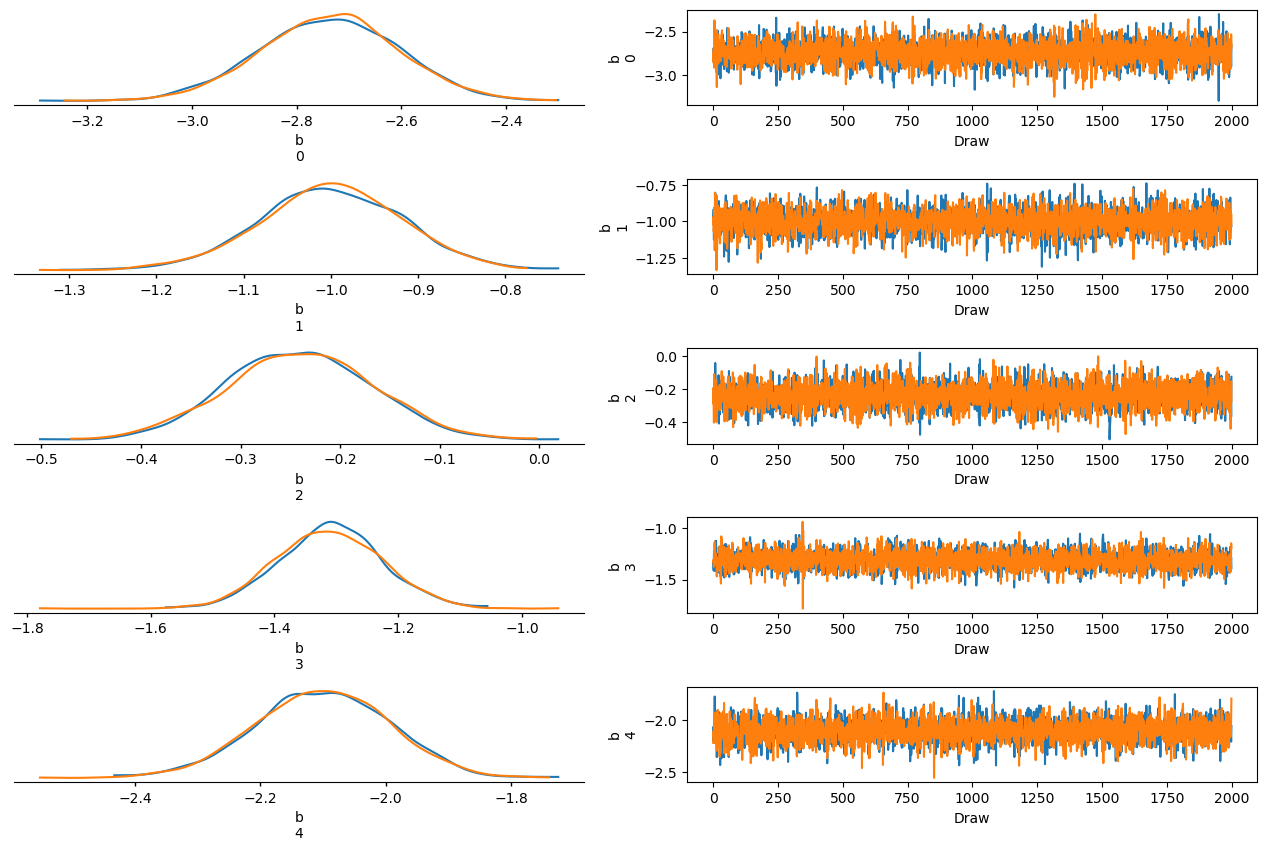

In [10]:
# Trace plot for b (difficulty parameters)
az.plot_trace_dist(idatas["1PL"], var_names=["b"], compact=False)
plt.tight_layout()


#### Interpretation of rank plots

A **rank plot** is often a more sensitive MCMC convergence diagnostic than a traditional trace plot.

The core idea is: first pool samples from all chains and sort them (ranking) by value, then examine how much each chain contributes to each rank bin. If the chains are mixing well and exploring the same posterior distribution, the contributions should be approximately uniform across ranks.

In `arviz` visualizations, the rank plot typically includes a gray **confidence envelope** that represents the range of random variation we would expect if all chains had perfectly converged and mixed well:

- **Good convergence**: each chain's curve (or bars) is roughly flat and stays mostly within the gray envelope, indicating that all chains explore the posterior space in a similar way.
- **Poor convergence**: if the curves show a clear monotone pattern (e.g., upward or downward), it suggests that some chains are systematically larger or smaller; U‑shaped or hump‑shaped curves indicate low sampling efficiency and insufficient exploration of some regions of the posterior.


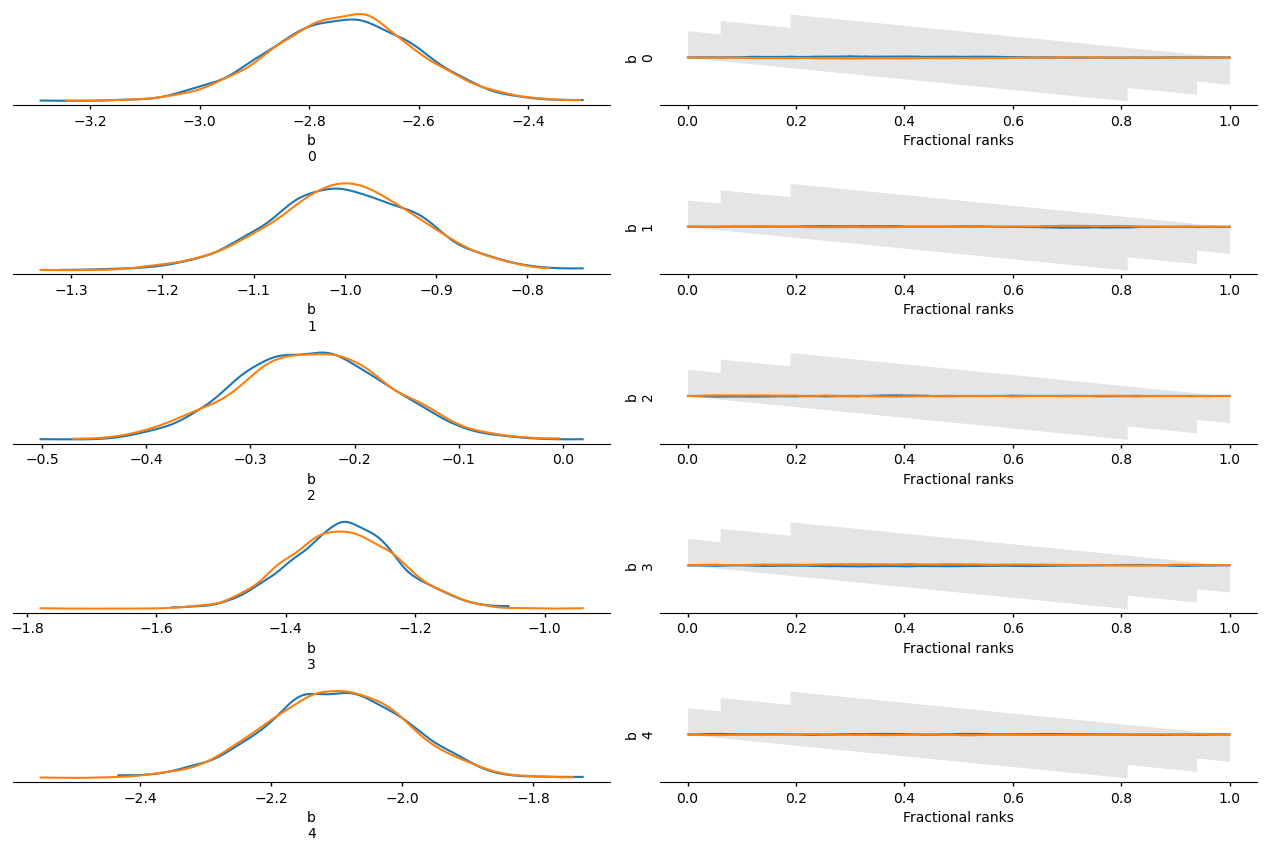

In [11]:
# Rank plot for b (difficulty parameters)
az.plot_rank_dist(idatas["1PL"], var_names=["b"], compact=False)
plt.tight_layout()


## Posterior predictive checks and PPP (absolute fit)

We use posterior predictive checks (PPC) to assess the absolute fit of the model.
Following the chi-square statistic for residuals (Sinharay, Johnson, & Stern, 2006):

$$\chi^2 = \sum_{i=1}^{N} \sum_{j=1}^{J} \frac{(y_{ij} - P_{ij})^2}{P_{ij}(1 - P_{ij})}$$

**Posterior Predictive P‑value (ppp)**: for each posterior draw, generate replicated data, compute $\chi^2_{\text{rep}}$ for the replicated data and $\chi^2_{\text{obs}}$ for the observed data (using the same $P_{ij}$ from that draw). The PPP is the posterior proportion
$$\mathbb{P}(\chi^2_{\text{rep}} \geq \chi^2_{\text{obs}}).$$

Sinharay, S., Johnson, M. S., & Stern, H. S. (2006). Posterior predictive assessment of item response theory models. *Applied Psychological Measurement*, *30*(4), 298‐321. https://doi.org/10.1177/0146621605285517

A ppp close to 0.5 typically indicates that the model fits the data reasonably well; values that are very small or very large suggest potential misfit and can be used together with WAIC/LOO for model selection.


In [12]:
def chi2_irt(y, p):
    """Chi-squared statistic for responses:
    sum_ij (y_ij - p_ij)^2 / (p_ij * (1 - p_ij)). Clips p for numerical stability."""
    eps = 1e-12
    p = np.clip(p, eps, 1.0 - eps)
    return (y - p) ** 2 / (p * (1.0 - p))

def posterior_predictive_p_value(data, idata):
    """Compute PPP using posterior samples: P(chi2_rep >= chi2_obs)."""
    # data:(N,J) -> (1,1,N,J); idata.posterior["p"]:(n_chains, n_draws, N, J)
    chi2_obs_arr = chi2_irt(data[None, None], idata.posterior["p"].values)
    # idata.posterior_predictive["y"]: (n_chains, n_draws, N, J)
    # idata.posterior["p"]: (n_chains, n_draws, N, J)
    chi2_rep_arr = chi2_irt(idata.posterior_predictive["y"].values,
                             idata.posterior["p"].values)
    ppp = np.mean(chi2_rep_arr.sum(axis=(-1, -2)) >= chi2_obs_arr.sum(axis=(-1, -2)))
    return ppp, chi2_obs_arr, chi2_rep_arr


In [13]:
# PPP for 2PL (example)
ppp_2pl, chi2_obs, chi2_rep = posterior_predictive_p_value(Y, idatas["2PL"])
print(f"Posterior Predictive P-value (PPP): {ppp_2pl:.4f}")
print(f"Mean chi2 (observed): {chi2_obs.sum(axis=(-1,-2)).mean():.2f}; Mean chi2 (replicated): {chi2_rep.sum(axis=(-1,-2)).mean():.2f}")


Posterior Predictive P-value (PPP): 0.4923
Mean chi2 (observed): 5023.37; Mean chi2 (replicated): 5003.82


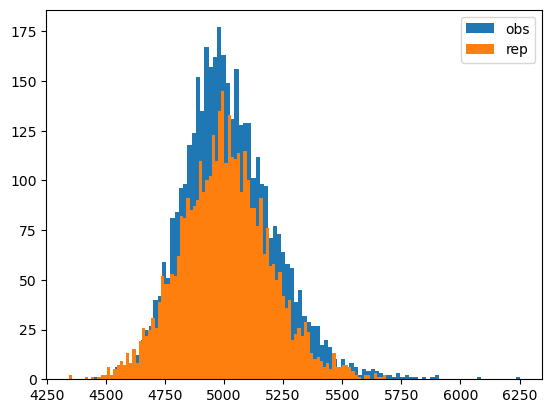

In [14]:
plt.hist(chi2_obs.sum(axis=(-1, -2)).flatten(), label="obs", color="C0", bins=100)
plt.hist(chi2_rep.sum(axis=(-1, -2)).flatten(), label="rep", color="C1", bins=100)
plt.legend()
plt.show()


# Model comparison (relative fit)

For each of the **1PL, 2PL, 3PL, and 4PL** models we run MCMC and then use `az.compare` to compare relative fit based on **WAIC** and **LOO**.

The columns returned by `az.compare` have the following meanings:

- **rank**: The rank-order of the models. 0 is the best.
- **elpd**: ELPD estimated using PSIS-LOO-CV (elpd_loo). Higher ELPD indicates higher out-of-sample predictive fit (“better” model).
- **pIC**: Estimated effective number of parameters.
- **elpd_diff**: The difference in ELPD between two models. If more than two models are compared, the difference is computed relative to the top-ranked model, that always has an elpd_diff of 0.
- **weight**: Relative weight for each model. This can be loosely interpreted as the probability of each model (among the compared models) given the data. By default the uncertainty in the weights estimation is considered using Bayesian bootstrap.
- **SE**: Standard error of the ELPD estimate. If method = BB-pseudo-BMA these values are estimated using Bayesian bootstrap.
- **dSE**: Standard error of the difference in ELPD between each model and the top-ranked model. It’s always 0 for the top-ranked model.
- **subsampling_dSE**: (Only when subsampling is used) The subsampling component of the standard error of the ELPD difference. This quantifies the uncertainty due to using a subsample rather than all observations.
- **warning**: A value of 1 indicates that the computation of the ELPD may not be reliable. This could be indication of LOO starting to fail see http://arxiv.org/abs/1507.04544 for details.

In [15]:
# Model comparison: WAIC and LOO
comparison = az.compare(idatas)
comparison


/Users/chenqipeng/miniconda3/envs/bayesian-psychometric/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/chenqipeng/miniconda3/envs/bayesian-psychometric/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observa

,rank,elpd,p,elpd_diff,weight,se,dse,warning
1PL,0,-2450.0,289.6,0.0,1.0,38.0,0.0,False
3PL,1,-2460.0,306.1,6.0,0.0,38.0,2.0,True
2PL,2,-2460.0,299.6,7.0,0.0,38.0,2.0,False
4PL,3,-2470.0,314.0,15.0,0.0,37.0,3.7,True


# Ridge plots (key parameters)

We summarize the posterior uncertainty of key parameters in the 1PL model using ridge plots via `az.plot_ridge`. Here we visualize the posterior distributions and intervals of the item difficulty parameters $b_1,\ldots,b_5$.


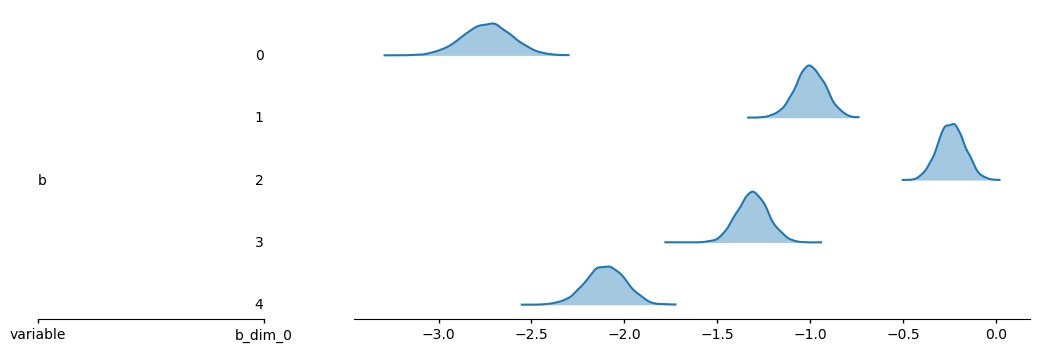

In [16]:
# Ridge plot: 1PL — b_1..b_5
az.plot_ridge(idatas["1PL"], var_names=["b"], combined=True);


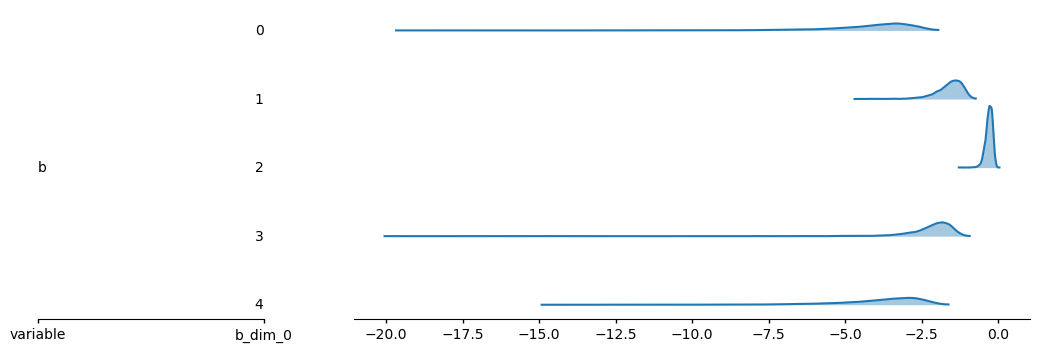

In [17]:
# Ridge plot: 2PL — b_1..b_5 (core difficulty parameters)
az.plot_ridge(idatas["2PL"], var_names=["b"], combined=True);
